# BEV GWP100, FaIR, and EDGES AWARE

**Purpose**

This notebook uses the imported passenger-car foreground inventory to assess the
battery electric car activity in three ways:

1. regular TRAILS LCIA with IPCC 2021 GWP100,
2. FaIR-derived radiative forcing and temperature anomaly from the same
   temporalized inventory,
3. EDGES-provided AWARE 2.0 water scarcity CFs for the same car.

The first part mirrors the regular premise + imported-LCI workflow. The EDGES
part creates a fresh `Trails` object so the GWP/FaIR results remain available in
`trails_gwp` while EDGES scores are stored in `trails_edges`.

In [1]:
import logging
import os
from pathlib import Path

import pandas as pd
from datapackage import Package

from trails import (
    Trails,
    get_edges_lcia_method_names,
    plot_temporal_scores,
    plot_rf,
    plot_temp,
    search_activity,
)
from trails.logging import configure_trails_logging
from trails.fair_rf import run_fair_delta_rf

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configure paths

`premise_path` points to the same local premise/TRAILS datapackage used in the
existing development notebook. Override it with the `TRAILS_PREMISE_PATH`
environment variable if needed.

In [2]:
configure_trails_logging(file_level=logging.INFO)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "trails").is_dir() and (candidate / "dev").is_dir():
            return candidate
    return start


def first_existing_path(candidates: list[Path]) -> Path:
    for candidate in candidates:
        candidate = candidate.expanduser()
        if candidate.exists():
            return candidate
    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"None of these paths exist:\n{checked}")


repo_root = find_repo_root()

premise_env = os.environ.get("TRAILS_PREMISE_PATH")
premise_candidates = []
if premise_env:
    premise_candidates.append(Path(premise_env))
premise_candidates.extend(
    [
        Path(
            "/Users/romain/Library/CloudStorage/OneDrive-PaulScherrerInstitut/"
            "trails/data/trails_2026-03-18.zip"
        ),
        repo_root / "dev" / "trails_2026-03-18.zip",
        Path("/Users/romain/GitHub/trails/dev/trails_2026-03-18.zip"),
    ]
)
premise_path = first_existing_path(premise_candidates)

inventory_path = first_existing_path(
    [
        repo_root / "dev" / "lci-pass_cars.xlsx",
        repo_root / "examples" / "lci-pass_cars.xlsx",
        Path("lci-pass_cars.xlsx"),
    ]
)

print("Repository root:", repo_root)
print("Premise datapackage:", premise_path)
print("Imported LCI workbook:", inventory_path)

Repository root: /Users/romain/GitHub/trails-edges-cfs
Premise datapackage: /Users/romain/Library/CloudStorage/OneDrive-PaulScherrerInstitut/trails/data/trails_2026-03-18.zip
Imported LCI workbook: /Users/romain/GitHub/trails-edges-cfs/dev/lci-pass_cars.xlsx


## 2. Helper functions

The notebook creates two independent `Trails` instances. Both import the same
Excel workbook and select the same battery electric car activity by metadata.

In [3]:
REF_YEAR = 2050
AMOUNT = 1.0
MAX_DEPTH = 4
BEV_NAME = "transport, passenger, car, battery electric"
BEV_LOCATION = "RER"


def make_trails() -> Trails:
    package = Package(str(premise_path))
    trails = Trails(
        package,
        interpolate_annual=True,
        debug=False,
        interpolation_start_year_offset=-20,
        interpolation_end_year_offset=20,
    )
    trails.import_excel_inventory(str(inventory_path))
    return trails


def select_bev_activity(trails: Trails) -> tuple[int, pd.DataFrame]:
    matches = search_activity(trails, "transport, passenger, car")
    matches_df = pd.DataFrame(matches.rows, columns=matches.field_names)

    exact = matches_df[matches_df["name"] == BEV_NAME].copy()
    if BEV_LOCATION is not None:
        exact = exact[exact["location"] == BEV_LOCATION]

    if len(exact) != 1:
        raise ValueError(
            "Expected exactly one BEV activity. Refine BEV_NAME or BEV_LOCATION."
        )

    return int(exact["index"].item()), exact

## 3. Load the foreground BEV activity

This first `Trails` object is used for regular GWP100 and the FaIR climate
emulator.

In [6]:
trails_gwp = make_trails()
bev_idx, bev_match = select_bev_activity(trails_gwp)

print("Template scenario years:", trails_gwp.template_labels)
print("Interpolated year range:", trails_gwp.min_year, "to", trails_gwp.max_year)
print("Selected BEV activity index:", bev_idx)
bev_match

Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_f64d88255796
Extracted 2 worksheets in 0.02 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 13 strategies in 0.01 seconds


KeyboardInterrupt: 

## 4. Inspect the imported BEV exchanges

The BEV foreground inventory includes production, operation, maintenance,
end-of-life, and temporally distributed exchanges. This is the same imported LCI
that will be used for GWP100, FaIR, and EDGES AWARE.

In [5]:
trails_gwp.print_exchange_table(year=REF_YEAR, act_idx=bev_idx)

Temporal distribution codes:
+------+--------------------------------------+
| code |             distribution             |
+------+--------------------------------------+
|  1   |      discrete (all mass at loc)      |
|  2   |              lognormal               |
|  3   |                normal                |
|  4   |               uniform                |
|  5   |              triangular              |
|  6   | discrete empirical (explicit pulses) |
+------+--------------------------------------+
Temporal distribution fields:
+------------------------+---------------------------------------+
|         field          |                meaning                |
+------------------------+---------------------------------------+
| temporal_distribution  |           distribution code           |
|      temporal_loc      | location parameter (mean/median/mode) |
|     temporal_scale     |     scale parameter (stddev/sigma)    |
|      temporal_min      |   minimum integer offset (inclus

## 5. Regular GWP100 temporal LCA

These are standard bundled TRAILS/LCIA methods. The result is stored on
`trails_gwp.scores`; `store_inventory=True` also keeps the temporalized
inventory needed by the FaIR step.

In [6]:
gwp_methods = [
    "IPCC 2021 - climate change: total (excl. biogenic CO2) - "
    "global warming potential (GWP100)",
    "IPCC 2021 (incl. biogenic CO2) - climate change: total "
    "(incl. biogenic CO2) - global warming potential (GWP100)",
]
gwp_methods

['IPCC 2021 - climate change: total (excl. biogenic CO2) - global warming potential (GWP100)',
 'IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)']

In [7]:
%%time
from trails.plotting import plot_temporal_graph

trails_gwp.temporal_routing(
    start_year=REF_YEAR,
    start_act_idx=bev_idx,
    amount=AMOUNT,
    max_depth=MAX_DEPTH,
    show_progress=True,
    attribute_to_roots=True,
)

plot_temporal_graph(
    trails_gwp,
    filename="trails_graph_bev_gwp.html",
    notebook=False,
)

trails_gwp.lca(
    methods=gwp_methods,
    show_progress=True,
    compute_score=True,
    store_inventory=True,
    solver_mode="iterative",
    iterative_rtol=1e-3,
)

trails_gwp.static_lca(
    year=REF_YEAR,
    act_idx=bev_idx,
    methods=gwp_methods,
    amount=AMOUNT,
)

static_gwp_score = trails_gwp.static_score
static_gwp_score

Temporal routing: 246846node [00:03, 77800.04node/s] 
Temporal LCA: solve years: 100%|██████████████████████████████████████████████████████| 90/90 [02:25<00:00,  1.62s/year]


CPU times: user 2min 45s, sys: 18.3 s, total: 3min 4s
Wall time: 3min 13s


[7554.445415939923, 7530.944885375353]

## 6. Compare temporal and static GWP100

The temporal score is summed over all non-method dimensions to make the total
comparable with the static single-year benchmark.

In [8]:
temporal_gwp = trails_gwp.scores
for dim in [dim for dim in temporal_gwp.dims if dim != "method"]:
    temporal_gwp = temporal_gwp.sum(dim=dim)

temporal_gwp_values = temporal_gwp.to_numpy().astype(float).ravel()
static_gwp_values = (
    static_gwp_score if isinstance(static_gwp_score, list) else [static_gwp_score]
)

gwp_comparison = pd.DataFrame(
    {
        "temporal_lca_score": temporal_gwp_values,
        "static_lca_score": [float(value) for value in static_gwp_values],
    },
    index=pd.Index(gwp_methods, name="method"),
)
gwp_comparison["difference"] = (
    gwp_comparison["temporal_lca_score"] - gwp_comparison["static_lca_score"]
)
gwp_comparison

,temporal_lca_score,static_lca_score,difference
method,,,
IPCC 2021 - climate change: total (excl. biogenic CO2) - global warming potential (GWP100),18236.53125,7554.445416,10682.085834
IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100),18236.53125,7530.944885,10705.586365


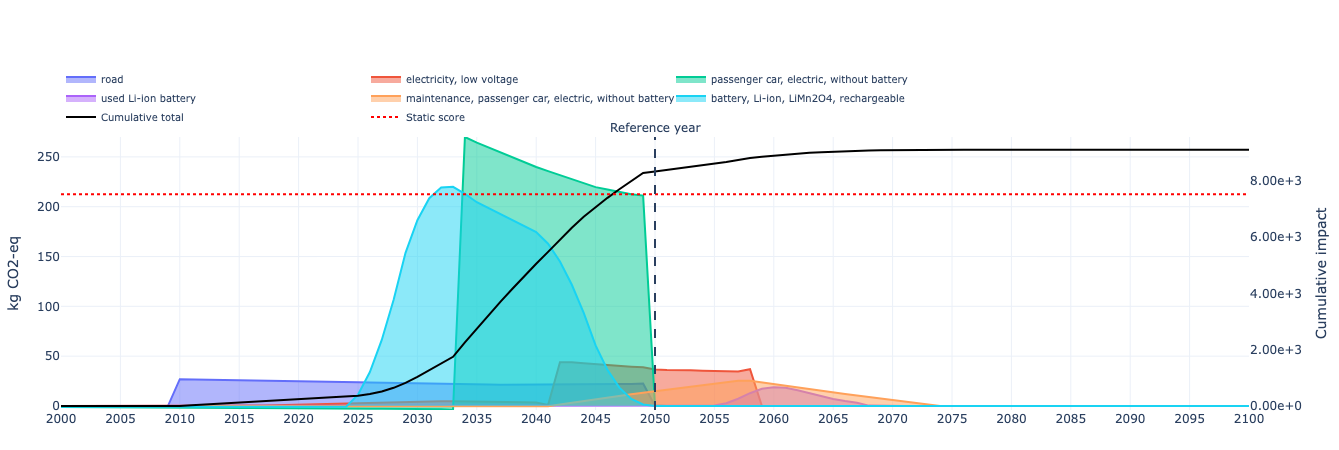

In [9]:
gwp_figs = plot_temporal_scores(
    trails=trails_gwp,
    stacked=False,
    legend_top_n=7,
    show_flow_contributions=False,
    title="BEV temporal GWP100",
    method_label="kg CO2-eq",
    cumulative=False,
    width=650,
    height=450,
    year_tick=5,
    year_range=(2000, 2100),
    reference_year=REF_YEAR,
    show_cumulative_axis=True,
    static_score=static_gwp_score,
    static_score_dash="dot",
    static_score_color="red",
)
gwp_figs[1]

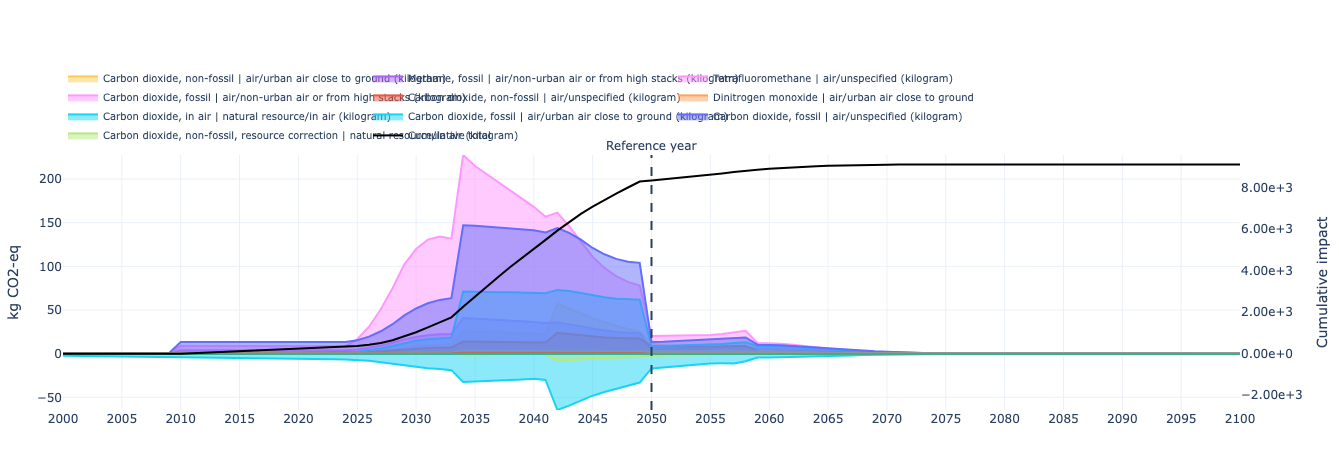

In [10]:
gwp_flow_figs = plot_temporal_scores(
    trails=trails_gwp,
    stacked=False,
    legend_top_n=10,
    show_flow_contributions=True,
    title="BEV temporal GWP100 by flow",
    method_label="kg CO2-eq",
    cumulative=False,
    width=650,
    height=450,
    year_tick=5,
    year_range=(2000, 2100),
    reference_year=REF_YEAR,
    show_cumulative_axis=True,
)
gwp_flow_figs[1]

## 7. FaIR radiative forcing and temperature anomaly

FaIR uses the stored temporalized inventory from the GWP run. The plots below
show radiative forcing and temperature anomaly for the same BEV foreground
activity.

In [11]:
%%time
fair_scenario = "REMIND|SSP2-PkBudg650"
run_fair_delta_rf(
    trails_gwp,
    scenario=fair_scenario,
)

FaIR per-species: 100%|███████████████████████████████████████████████████████| 27/27 [03:24<00:00,  7.58s/run, N2O:pos]


CPU times: user 3min 19s, sys: 55 s, total: 4min 14s
Wall time: 4min 12s


Format,coo
Data Type,float64
Shape,"(5, 751, 9850, 41796)"
nnz,721539
Density,4.667441870362275e-07
Read-only,True
Size,27.5M
Storage ratio,0.00


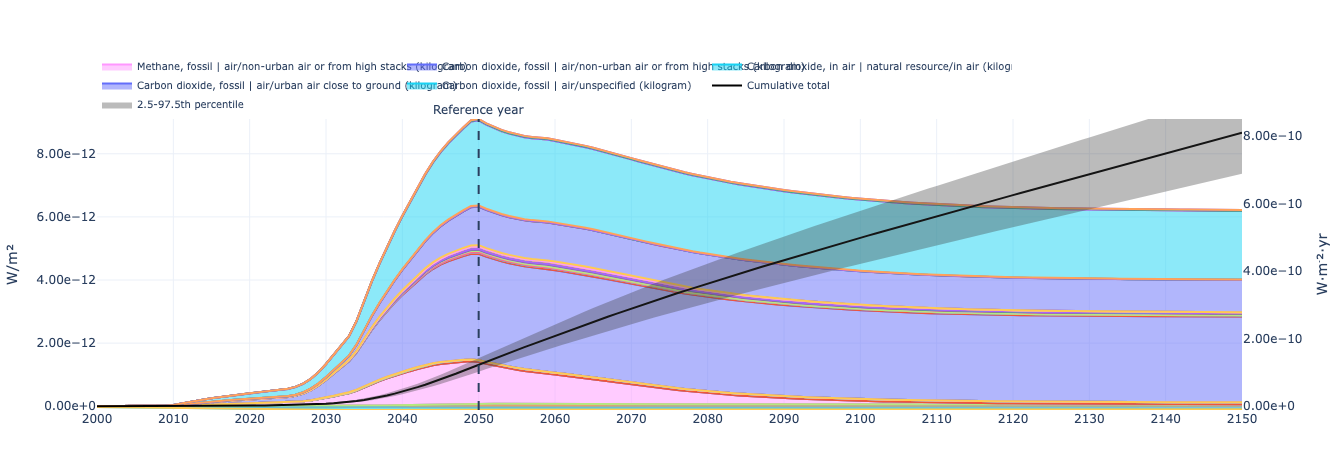

In [12]:
plot_rf(
    trails=trails_gwp,
    reference_year=REF_YEAR,
    by="flow",
    year_range=(2000, 2150),
    year_tick=10,
)

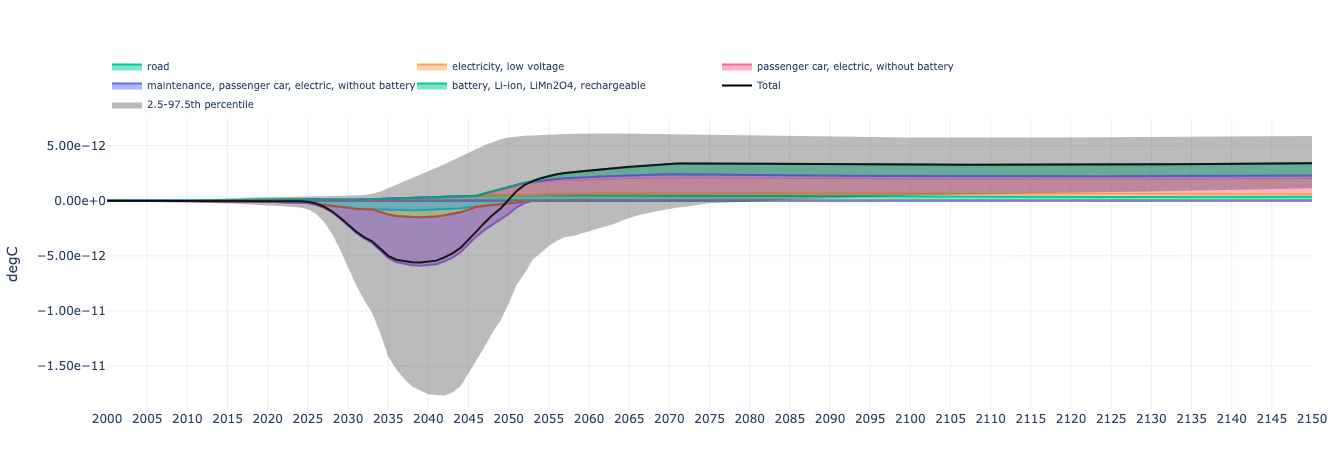

In [13]:
plot_temp(
    trails_gwp,
    by="root activity",
    title="BEV temperature anomaly by root activity",
    method_label="degC",
    year_range=(2000, 2150),
)

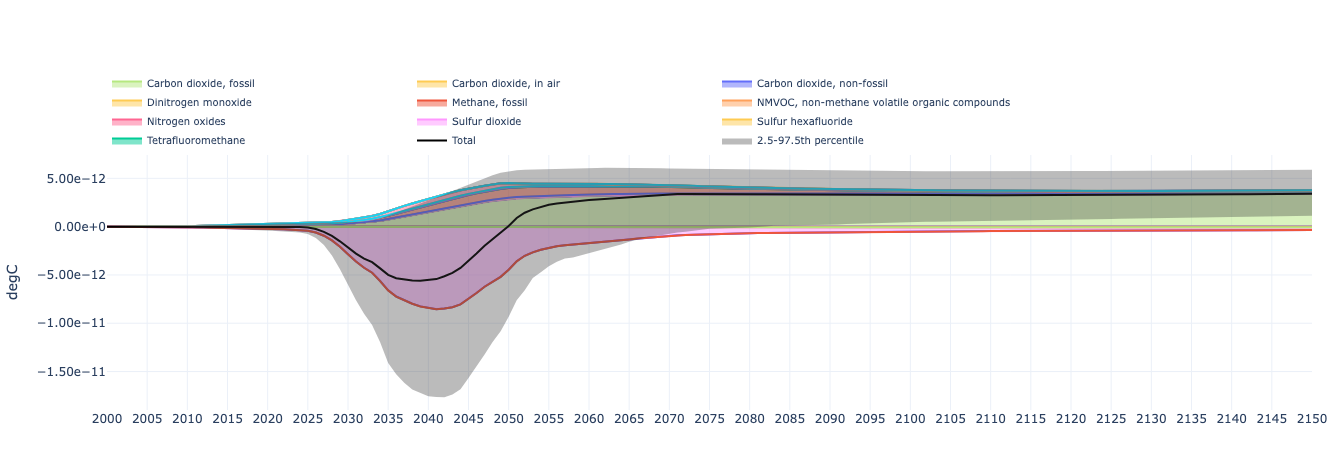

In [14]:
plot_temp(
    trails_gwp,
    by="flow",
    title="BEV temperature anomaly by flow",
    method_label="degC",
    year_range=(2000, 2150),
    legend_top_n=10,
    flow_groupby_name=True,
)

## 8. EDGES AWARE 2.0 for the same BEV activity

EDGES provides edge-level characterization factors. Here, the supplier is a
biosphere water flow and the consumer is the activity receiving that exchange,
so the same flow can receive different AWARE CFs depending on the consuming
activity location.

This step requires the optional `edges` package. The new `edges_methods` argument
is mutually exclusive with regular `methods`.

In [4]:
available_edges_methods = get_edges_lcia_method_names()
aware_methods = [method for method in available_edges_methods if method[:2] == ("AWARE 2.0", "Country")]
aware_methods

[('AWARE 2.0', 'Country', 'all', 'yearly'),
 ('AWARE 2.0', 'Country', 'irri', 'yearly'),
 ('AWARE 2.0', 'Country', 'non', 'irri', 'yearly'),
 ('AWARE 2.0', 'Country', 'unspecified', 'yearly')]

In [5]:
edges_aware_method = ("AWARE 2.0", "Country", "all", "yearly")
if edges_aware_method not in available_edges_methods:
    raise ValueError(f"EDGES method not available: {edges_aware_method}")

trails_edges = make_trails()
bev_idx_edges, bev_match_edges = select_bev_activity(trails_edges)
bev_match_edges

Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_f64d88255796
15:17:08+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.
Extracted 2 worksheets in 0.28 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 13 strategies in 0.00 seco

,index,name,reference product,location
106,41793,"transport, passenger, car, battery electric","transport, passenger, car",RER


In [6]:
%%time
trails_edges.temporal_routing(
    start_year=REF_YEAR,
    start_act_idx=bev_idx_edges,
    amount=AMOUNT,
    max_depth=MAX_DEPTH,
    show_progress=True,
    attribute_to_roots=True,
)

trails_edges.lca(
    edges_methods=[edges_aware_method],
    show_progress=True,
    compute_score=True,
    store_inventory=False,
    solver_mode="iterative",
    iterative_rtol=1e-3,
)

trails_edges.scores

Temporal routing: 246846node [00:04, 55155.99node/s] 
EDGES LCIA: 100%|██████████████████| 89/89 [15:42<00:00, 10.59s/method-year, year=2073, method=1/1, edges=405921, new=0]


CPU times: user 13min 6s, sys: 3min 47s, total: 16min 54s
Wall time: 19min 25s


Format,coo
Data Type,float32
Shape,"(41796, 886, 41796)"
nnz,1865666
Density,1.2053987425941794e-06
Read-only,True
Size,49.8M
Storage ratio,0.00


## 9. Summarize and plot EDGES AWARE scores

The EDGES AWARE result is a temporal score in `m3 deprived water-eq.` for the
same BEV functional unit used above.

In [7]:
aware_total = trails_edges.scores
for dim in aware_total.dims:
    aware_total = aware_total.sum(dim=dim)

aware_total_value = float(aware_total.to_numpy())
print("Total EDGES AWARE score:", aware_total_value, "m3 deprived water-eq.")

Total EDGES AWARE score: 4760.5537109375 m3 deprived water-eq.


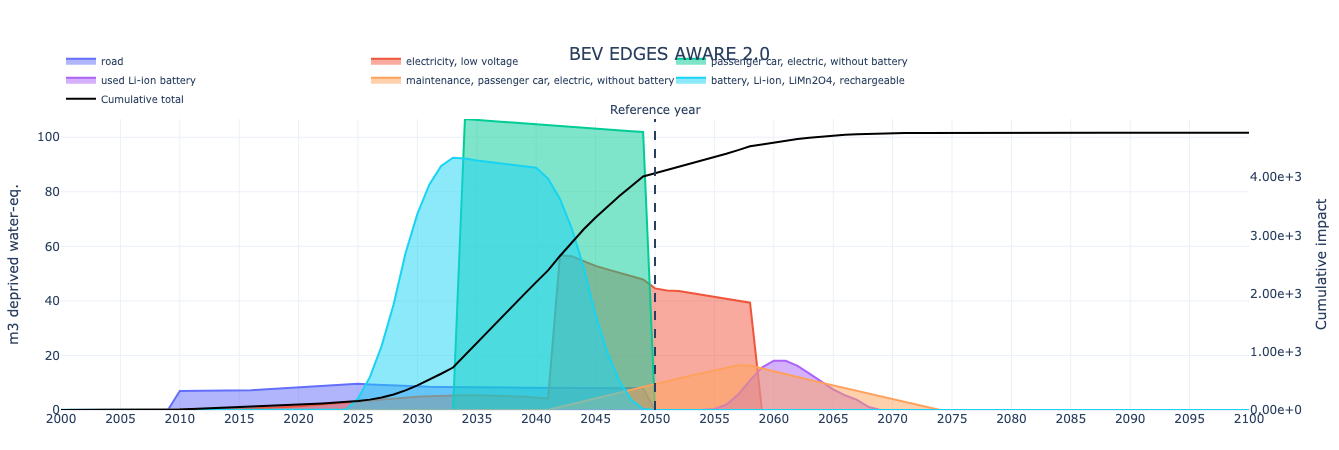

In [8]:
aware_fig = plot_temporal_scores(
    trails=trails_edges,
    stacked=False,
    legend_top_n=10,
    show_flow_contributions=False,
    title="BEV EDGES AWARE 2.0",
    method_label="m3 deprived water-eq.",
    cumulative=False,
    width=650,
    height=450,
    year_tick=5,
    year_range=(2000, 2100),
    reference_year=REF_YEAR,
    show_cumulative_axis=True,
)
aware_fig

In [9]:
aware_by_root = trails_edges.scores.sum(
    dim=[dim for dim in trails_edges.scores.dims if dim != "root activity"]
)
root_values = aware_by_root.to_numpy().astype(float).ravel()
root_ids = aware_by_root.coords["root activity"].values.astype(int)
activity_metadata = next(iter(trails_edges.activity_indices.values()))

aware_root_contributors = pd.DataFrame(
    {
        "root activity": root_ids,
        "score": root_values,
        "name": [activity_metadata.get(int(idx), {}).get("name") for idx in root_ids],
        "reference product": [
            activity_metadata.get(int(idx), {}).get("reference product")
            for idx in root_ids
        ],
        "location": [
            activity_metadata.get(int(idx), {}).get("location") for idx in root_ids
        ],
    }
)
aware_root_contributors = aware_root_contributors[
    aware_root_contributors["score"] != 0
].copy()
aware_root_contributors["abs_score"] = aware_root_contributors["score"].abs()
aware_root_contributors.sort_values("abs_score", ascending=False).head(10)


,root activity,score,name,reference product,location,abs_score
12988,12988,1667.059570,"passenger car production, electric, without ba...","passenger car, electric, without battery",GLO,1667.059570
23432,23432,1461.918091,"market for battery, Li-ion, LiMn2O4, rechargeable","battery, Li-ion, LiMn2O4, rechargeable",GLO,1461.918091
7819,7819,893.470459,"market group for electricity, low voltage","electricity, low voltage",RER,893.470459
5615,5615,326.995453,road construction,road,RoW,326.995453
17065,17065,279.937592,"market for maintenance, passenger car, electri...","maintenance, passenger car, electric, without ...",GLO,279.937592
13289,13289,131.172363,market for used Li-ion battery,used Li-ion battery,GLO,131.172363
